#### Project 02: Customer Analytics & Business Insights
**Name:** Elham Azari  
**Goal:** Analyzing customer behavior to aid executive decisions.

In [4]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set chart styling
sns.set_theme(style="whitegrid")

In [5]:
df = pd.read_excel('cleaned_dataset_Elham-Azari.xlsx')
df.head()

,customer_id,first_name,gender,age,city,province,signup_date,membership_tier,purchase_count,avg_order_value,total_spending,last_purchase_days,payment_method,device,discount_used,returned_items,satisfaction_score,return_issue_flag
0,1001,Reza,Male,19,Karaj,Alborz,2025-02-19,Vip,17,121.53,2066.01,16,Card,Android,Yes,3,5,False
1,1002,Sina,Male,53,Tehran,Tehran,2022-08-19,Gold,12,326.47,3917.64,3,Card,Web,No,5,3,False
2,1003,Parsa,Male,31,Shiraz,Fars,2023-06-20,Gold,21,59.46,1248.66,22,Online Wallet,Iphone,Yes,6,1,False
3,1004,Sina,Male,58,Mashhad,Khorasan,2021-11-08,Gold,23,266.15,6121.45,40,Card,Android,No,4,4,False
4,1005,Kimia,Female,28,Esfahan,Esfahan,2021-10-21,Silver,23,169.54,3899.42,273,Online Wallet,Android,Yes,7,4,False


--- 
### Key Metrics

In [6]:
# Calculate core KPIs
total_revenue = df['total_spending'].sum()
total_customers = df['customer_id'].nunique()
avg_spend = df['total_spending'].mean()

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Customers: {total_customers}")
print(f"Average Spend: ${avg_spend:,.2f}")

Total Revenue: $201,985.73
Total Customers: 60
Average Spend: $3,366.43


--- 
####  Revenue by City
Checking which city generates the most sales for our next marketing run.

In [7]:
# Group by city to see performance
city_analysis = df.groupby('city').agg(
    total_revenue=('total_spending', 'sum'),
    customer_count=('customer_id', 'count'),
    avg_spend=('total_spending', 'mean')
).sort_values(by='total_revenue', ascending=False)

print(city_analysis)

# Get the top performing city
top_city = city_analysis.index[0]
print(f"\nRecommended City for Marketing: {top_city}")

         total_revenue  customer_count    avg_spend
city                                               
Mashhad       43197.58              11  3927.052727
Tabriz        36192.49              12  3016.040833
Karaj         26189.81               7  3741.401429
Ahvaz         23384.78               8  2923.097500
Esfahan       21975.32               5  4395.064000
Shiraz        20715.92               6  3452.653333
Rasht         15168.54               5  3033.708000
Tehran        15161.29               6  2526.881667

Recommended City for Marketing: Mashhad


#### 5. Top 10 Customers
Finding our most valuable customers for VIP rewards.

In [8]:
# Extract top 10 highest spending customers
top_10_customers = df.nlargest(10, 'total_spending')[['customer_id', 'city', 'total_spending']]

print("Top 10 Customers:")
print(top_10_customers)

Top 10 Customers:
    customer_id     city  total_spending
43         1044   Shiraz        14354.34
56         1057    Ahvaz        13532.74
11         1012  Mashhad        11731.50
8          1009    Karaj        11615.42
58         1059  Esfahan         8898.55
9          1010    Karaj         7241.47
49         1050  Mashhad         6198.00
3          1004  Mashhad         6121.45
54         1055    Rasht         6068.22
34         1035   Tabriz         5918.21


#### Identifying At-Risk Customers
Finding low-spending customers (bottom 25%) who might need retention offers.

In [9]:
# Identify customers in the lowest 25% spending bracket
spend_threshold = df['total_spending'].quantile(0.25)
at_risk_customers = df[df['total_spending'] <= spend_threshold]

print(f"Spend threshold for at-risk (25th percentile): ${spend_threshold:,.2f}")
print(f"Number of At-Risk Customers: {len(at_risk_customers)}")

# Preview bottom customers
at_risk_customers[['customer_id', 'city', 'total_spending']].head(10)

Spend threshold for at-risk (25th percentile): $1,167.04
Number of At-Risk Customers: 15


,customer_id,city,total_spending
12,1013,Karaj,270.91
14,1015,Ahvaz,923.73
20,1021,Tabriz,1161.92
23,1024,Ahvaz,0.00
24,1025,Mashhad,812.06
28,1029,Tabriz,646.64
35,1036,Karaj,1040.40
36,1037,Ahvaz,387.68
37,1038,Mashhad,856.53
38,1039,Shiraz,405.57


#### Impact of Discount Codes
Comparing spending patterns between discount users and regular buyers.

In [10]:
# Compare discount vs non-discount performance
discount_comparison = df.groupby('discount_used').agg(
    customer_count=('customer_id', 'count'),
    avg_spend=('total_spending', 'mean'),
    total_revenue=('total_spending', 'sum')
)

print("Discount vs Non-Discount Performance:")
print(discount_comparison)

Discount vs Non-Discount Performance:
               customer_count    avg_spend  total_revenue
discount_used                                            
No                         34  3736.741176      127049.20
Yes                        26  2882.174231       74936.53


#### Customer Segmentation
Grouping customers into Low, Medium, and High value tiers based on spend.

In [11]:
# Segment customers into 3 equal-sized tiers based on spending
labels = ['Low Value', 'Medium Value', 'High Value']
df['customer_segment'] = pd.qcut(df['total_spending'], q=3, labels=labels)

segment_summary = df.groupby('customer_segment', observed=False).agg(
    customer_count=('customer_id', 'count'),
    total_revenue=('total_spending', 'sum'),
    avg_spend=('total_spending', 'mean')
)

print("Customer Segmentation Breakdown:")
print(segment_summary)

Customer Segmentation Breakdown:
                  customer_count  total_revenue  avg_spend
customer_segment                                          
Low Value                     20       16739.57   836.9785
Medium Value                  20       47984.34  2399.2170
High Value                    20      137261.82  6863.0910


#### Pareto Analysis (80/20 Rule)
Checking if a small percentage of top customers generates the majority of revenue.

In [13]:
# Sort dataset by total spending in descending order
df_sorted = df.sort_values(by='total_spending', ascending=False).reset_index(drop=True)

# Calculate cumulative metrics
df_sorted['cum_revenue'] = df_sorted['total_spending'].cumsum()
df_sorted['cum_perc_revenue'] = 100 * df_sorted['cum_revenue'] / total_revenue
df_sorted['cum_perc_customers'] = 100 * (df_sorted.index + 1) / len(df_sorted)

# Find revenue generated by top 20% of customers
top_20_pct_rev = df_sorted[df_sorted['cum_perc_customers'] <= 20]['cum_perc_revenue'].max()
print(f"Top 20% of customers generate {top_20_pct_rev:.2f}% of total revenue.")

Top 20% of customers generate 51.00% of total revenue.


--- 
### Task 8: CEO Executive Dashboard (Visualization)
Visualizing 4 key aspects of customer data for executive leadership.

C:\Users\Windows 10\AppData\Local\Temp\ipykernel_14004\884915629.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_analysis.index, y=city_analysis['total_revenue'], ax=axes[0,0], palette='Blues_r')


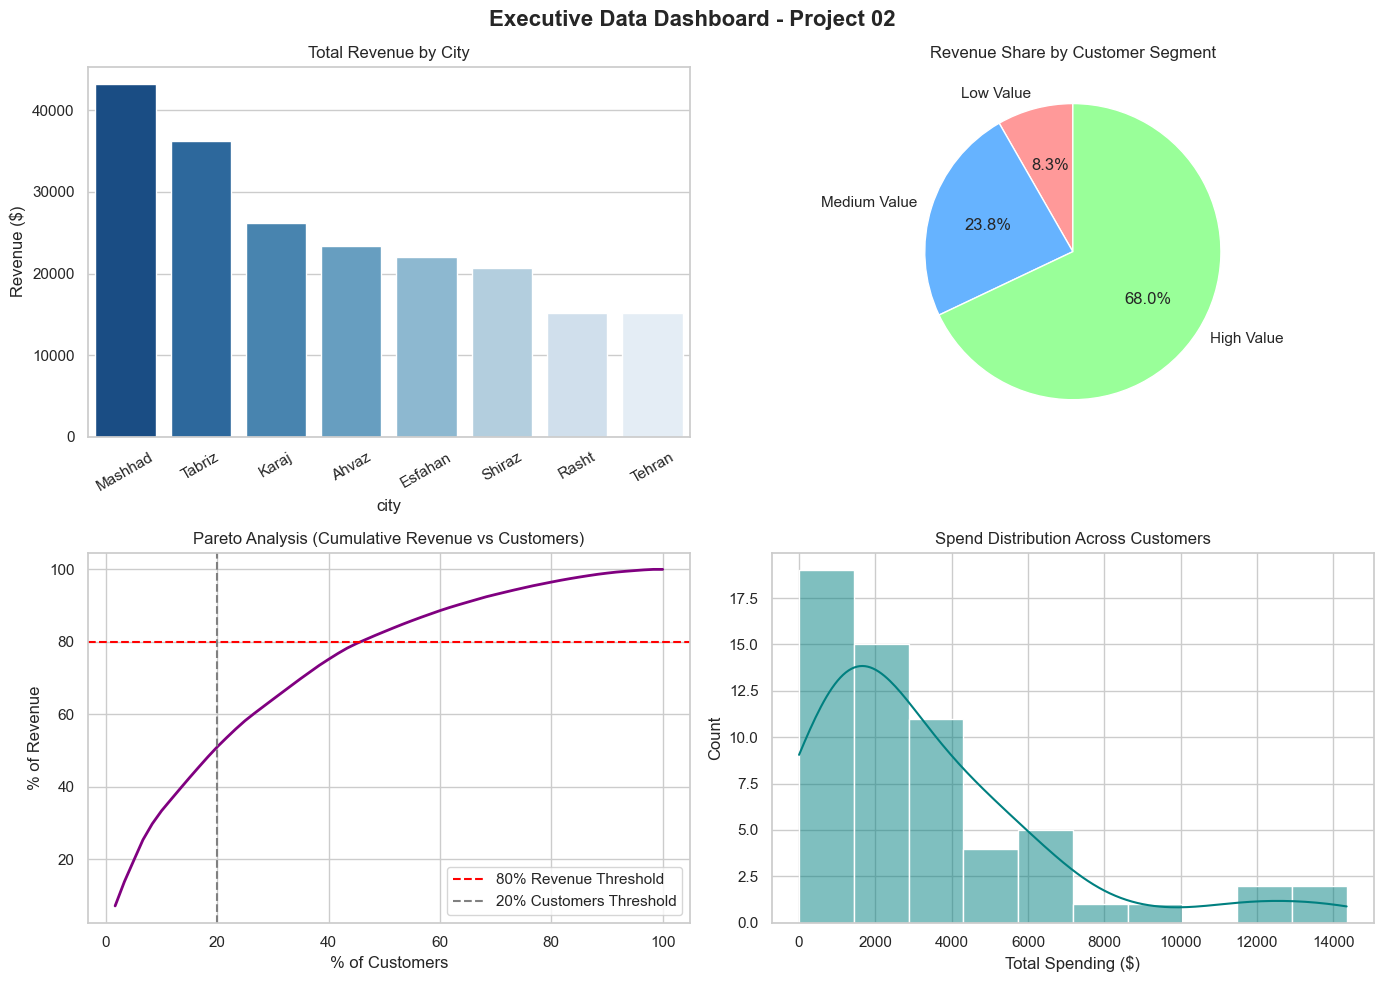

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
plt.suptitle('Executive Data Dashboard - Project 02', fontsize=16, fontweight='bold')

# Chart 1: Revenue by City
sns.barplot(x=city_analysis.index, y=city_analysis['total_revenue'], ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title('Total Revenue by City')
axes[0,0].set_ylabel('Revenue ($)')
axes[0,0].tick_params(axis='x', rotation=30)

# Chart 2: Revenue Share by Customer Segment (FIXED)
segment_summary['total_revenue'].plot(kind='pie', autopct='%1.1f%%', ax=axes[0,1], colors=['#ff9999','#66b3ff','#99ff99'], startangle=90)
axes[0,1].set_title('Revenue Share by Customer Segment')
axes[0,1].set_ylabel('')

# Chart 3: Pareto Curve
axes[1,0].plot(df_sorted['cum_perc_customers'], df_sorted['cum_perc_revenue'], color='purple', lw=2)
axes[1,0].axhline(80, color='red', linestyle='--', label='80% Revenue Threshold')
axes[1,0].axvline(20, color='grey', linestyle='--', label='20% Customers Threshold')
axes[1,0].set_title('Pareto Analysis (Cumulative Revenue vs Customers)')
axes[1,0].set_xlabel('% of Customers')
axes[1,0].set_ylabel('% of Revenue')
axes[1,0].legend()

# Chart 4: Spend Distribution
sns.histplot(df['total_spending'], kde=True, ax=axes[1,1], color='teal')
axes[1,1].set_title('Spend Distribution Across Customers')
axes[1,1].set_xlabel('Total Spending ($)')

plt.tight_layout()
plt.savefig('dashboard_summary.png', dpi=300)
plt.show()

---
### Business Insights & Recommendations

#### Key Recommendations:
1. **Focus on Top Cities:** Mashhad and Tabriz brought in the highest revenue. It makes sense to focus our upcoming marketing budgets and ads primarily on these cities.
2. **VIP Customer Loyalty Program:** Our top 20% of customers generate over half of our total revenue. Setting up a dedicated loyalty or VIP reward program for them will help keep them engaged and prevent churn.
3. **Re-evaluating Discounts:** Surprisingly, customers who bought without discounts had a higher average spend than those who used discount codes. We should rethink how we offer discounts so we don't unnecessarily slice into our margins.

#### Dataset Limitations:
- **No Timestamps:** Without order dates, we couldn't run time-based trends or RFM (Recency, Frequency, Monetary) analysis over time.
- **No Product Details:** The data lacks item categories or product names, so we couldn't analyze which products or categories sell best.